# Cross Domain sensing results

In [8]:
import os
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import torch

def load_tensorboard_events(file_path):
    # Create an EventAccumulator to load the event file.
    # The 'size_guidance' argument can be used to control how many items to load for each type.
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 1000,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file

    # Print available tags
    tags = ea.Tags()
    print("Available Tags:", tags)

    # For example, to print all scalar events for each scalar tag:
    if 'scalars' in tags:
        for tag in tags['scalars']:
            print(f"\nScalar values for tag: {tag}")
            events = ea.Scalars(tag)
            for event in events:
                print(f"Step: {event.step}, Value: {event.value}")
                

def load_tensorboard_metrics(file_path):
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 100,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file
    tags = ea.Tags()
    metrics = tags['scalars']
    
    return_dict = {
        'best_model_epoch': None,
        'in-domain test metric (per sample)': None,
        'test metric (per sample)': None,
    }
    
    for tag in metrics:
        if 'in-domain test metric' in tag:
            return_dict['in-domain test metric (per sample)'] = ea.Scalars(tag)[0].value
            return_dict['best_model_epoch'] = ea.Scalars(tag)[0].step   
        elif 'test metric' in tag:
            return_dict['test metric (per sample)'] = ea.Scalars(tag)[0].value
    return return_dict  


def load_series_metrics(tensor_board_dir, model_metrics):
    unmatched_sub_fodlers = []
    sub_fodlers = os.listdir(tensor_board_dir)
    models = model_metrics.keys()
    for sub_folder in sub_fodlers:
        sub_folder_path = os.path.join(tensor_board_dir, sub_folder)
        files = os.listdir(sub_folder_path)
        # find the key that in the sub_folder
        key = None
        for model in models:
            if model in sub_folder:
                key = model
                break
        if key is None:
            unmatched_sub_fodlers.append(sub_folder)
            continue
        for file in files:
            if file.startswith("events.out.tfevents"):
                file_path = os.path.join(sub_folder_path, file)
                metrics = load_tensorboard_metrics(file_path)
                metrics['sub_folder'] = sub_folder
                model_metrics[key].append(metrics)
    return model_metrics, unmatched_sub_fodlers


def MPJPE_2D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 2)
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 2)
    labels = labels.reshape(labels.shape[0], -1, 2)
    per_sample_mpjpe = np.mean(np.abs(np.linalg.norm(predicts - labels, axis=2)), axis=1)
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

def MPJPE_3D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 3) 
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 3)
    labels = labels.reshape(labels.shape[0], -1, 3)
    per_sample_mpjpe = np.mean(np.linalg.norm(predicts - labels, axis=2), axis=1)
    # if there is any value less than 0, print the index
    if np.any(per_sample_mpjpe < 0):
        print("less than 0")
        print(np.where(per_sample_mpjpe < 0))
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

def accuracy(predicts, labels):
    # predicts: (batch_size, num_classes)
    # labels: (batch_size, )
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = np.argmax(predicts, axis=1)
    return np.sum(predicts == labels) / len(labels)

## Widar3.0 G6 (Cross-user and room)

### In-Domain results

In [9]:
all_results_folder = 'logs/widar3G6/'

results_files = [
    'widar3G6_rfcrate_small_rf_crate_small_0128000257_indomain_test',
]

model_names = [
    'RF-CRATE'
    ]

accuracy_cross_user_list = []
accuracy_cross_orientation_list = []
accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)

        # user ids
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break

for index, name in enumerate(model_names):
    print(name)
    print(accuracy_cross_user_list[index])

RF-CRATE
{8: 0.8678571428571429, 9: 0.8579234972677595, 3: 0.95, 7: 0.8536060279870828}


### Cross-Domain results

In [10]:
results_files = [
    'widar3G6_rfcrate_small_rf_crate_small_0128000257',
]

model_names = [
    'RF-CRATE'
    ]


cross_accuracy_cross_user_list = []
cross_accuracy_cross_orientation_list = []
cross_accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)
        
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        cross_accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        cross_accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        cross_accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break

for index, name in enumerate(model_names):
    print(name)
    print(cross_accuracy_cross_user_list[index])
    

RF-CRATE
{1: 0.7396251673360107, 5: 0.7257920571173583, 6: 0.8139897527288928, 10: 0.7061324977618622, 11: 0.7051224944320713, 12: 0.7310905396251975, 13: 0.7914069456812111, 14: 0.8059834784550123, 15: 0.7743086529884032, 16: 0.8028169014084507}


### Fig. 14. Performance evaluation of RF-CRATE across multiple users and environments.

[0.7257920571173583, 0.7061324977618622, 0.7051224944320713, 0.7310905396251975, 0.7914069456812111, 0.8059834784550123, 0.7743086529884032, 0.8028169014084507, 0.7396251673360107, 0.8139897527288928, 0.95, 0.8536060279870828, 0.8678571428571429, 0.8579234972677595]
[5, 10, 11, 12, 13, 14, 15, 16, 1, 6, 3, 7, 8, 9]


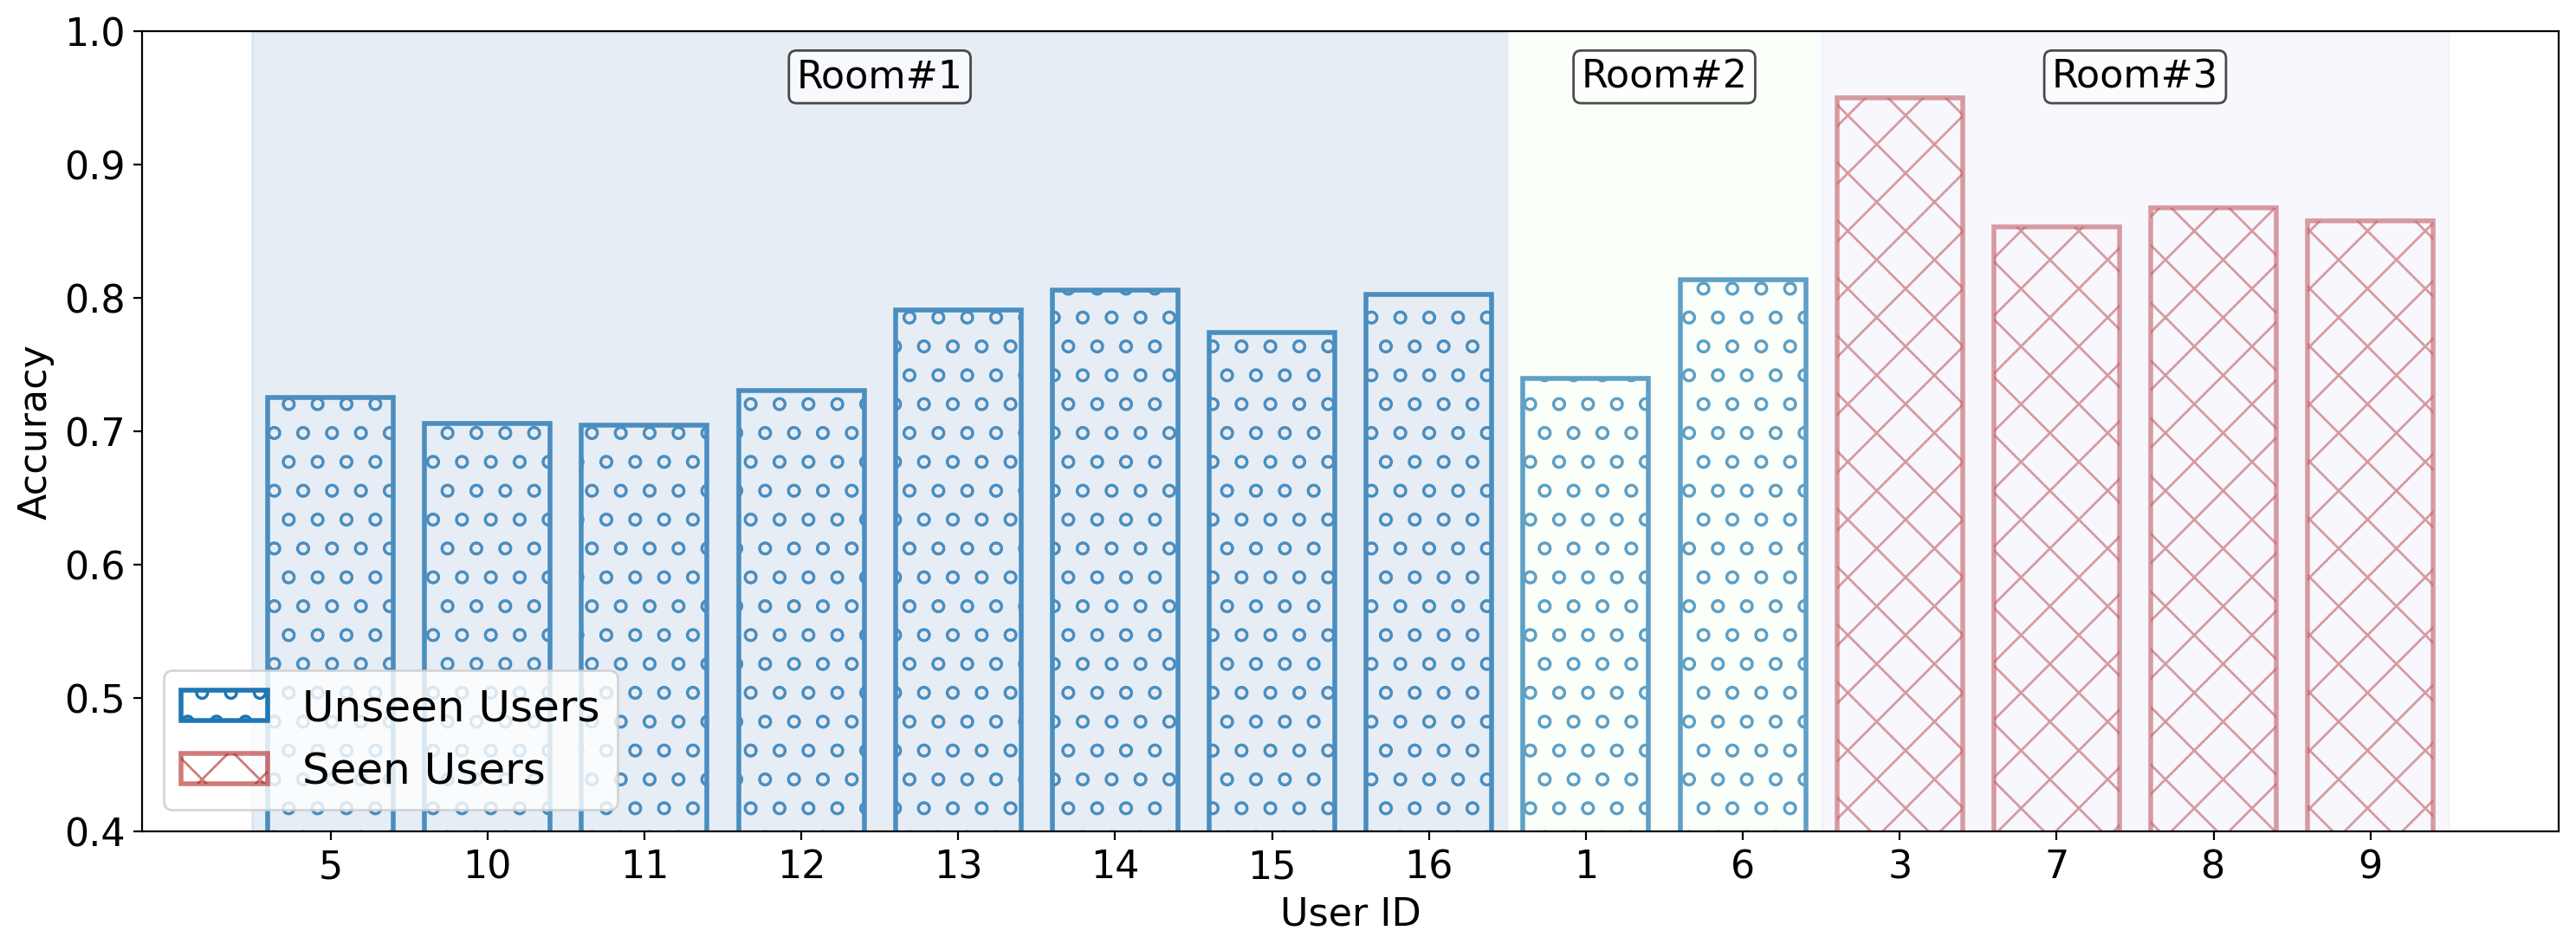

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Combine data
in_domain_results = {8: 0.8678571428571429, 9: 0.8579234972677595, 3: 0.95, 7: 0.8536060279870828}
cross_domain_results = {1: 0.7396251673360107, 5: 0.7257920571173583, 6: 0.8139897527288928, 10: 0.7061324977618622,
                        11: 0.7051224944320713, 12: 0.7310905396251975, 13: 0.7914069456812111, 14: 0.8059834784550123, 
                        15: 0.7743086529884032, 16: 0.8028169014084507}

rooms_users = {
    'Room#1': [5, 10, 11, 12, 13, 14, 15, 16],
    'Room#2': [1, 6],
    'Room#3': [3, 7, 8, 9]
}

user_id = rooms_users['Room#1'] + rooms_users['Room#2'] + rooms_users['Room#3']
acc = [in_domain_results[u_id] if u_id in in_domain_results else cross_domain_results[u_id] for u_id in user_id]
print(acc)  
print(user_id)

x_ticks = np.arange(len(user_id)) 

# draw the bar plot
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 16}) 

plt.figure(figsize=(18, 6), dpi=200)
plt.bar(x_ticks[:-4], acc[:-4], capsize=8, facecolor='none', hatch='o',edgecolor='tab:blue', linewidth=2)
plt.bar(x_ticks[-4:], acc[-4:], capsize=8, facecolor='none', hatch='X', edgecolor='firebrick', linewidth=2, alpha=0.6)

# add x-label
plt.xlabel('User ID')
plt.xticks(x_ticks, user_id,)

plt.legend(['Unseen Users', 'Seen Users'], loc='lower left', fontsize=18)
plt.ylim(0.4,1)
plt.ylabel('Accuracy')

# Add background colors based on room number
room_colors = {
    'Room#1': 'lightsteelblue', 
    'Room#2': 'honeydew', 
    'Room#3': 'lavender'
}

# Create room ranges for background
room_ranges = []
start_idx = 0
for room, users in rooms_users.items():
    end_idx = start_idx + len(users)
    room_ranges.append((start_idx, end_idx, room))
    start_idx = end_idx

# Add background colors for each room
for start, end, room in room_ranges:
    plt.axvspan(start - 0.5, end - 0.5, alpha=0.3, color=room_colors[room])
    # Add room label at the center of each region
    plt.text((start + end - 1) / 2, 0.98, room, ha='center', va='top', fontsize=16,
             bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

# plt.tight_layout()
# plt.savefig("figures/v2_cross_userANDroom_wide_figure" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()

## Widar3.0 G6CD Cross Device and orientation

In [11]:
all_results_folder = 'logs/widar3G6CD/'

results_files = [
    'widar3G6CD_rfcrate_small_rf_crate_small_0306194346_indomain_test',
]

model_names = [
    'RF-CRATE'
    ]

accuracy_cross_user_list = []
accuracy_cross_orientation_list = []
accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)
        
        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break

for index, name in enumerate(model_names):
    print(name)
    print(accuracy_cross_orientation_list[index])
    print(accuracy_cross_rx_list[index])
    

RF-CRATE
{1: 0.8559556786703602, 2: 0.8846153846153846, 3: 0.8328690807799443, 4: 0.8213333333333334, 5: 0.83008356545961}
{1: 0.8665568369028006, 3: 0.8183361629881154, 5: 0.8473154362416108}


In [12]:
results_files = [
    'widar3G6CD_rfcrate_small_rf_crate_small_0306194346',
]

model_names = [
    'RF-CRATE'
    ]


cross_accuracy_cross_user_list = []
cross_accuracy_cross_orientation_list = []
cross_accuracy_cross_rx_list = []


for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        predicts = results['predicts']
        labels = results['labels']
        attributes = results['attributes']
        
        user_ids = []
        orientations = []
        rx_ids = []
        for i in range(len(attributes)):
            user_id = attributes[i][0].numpy()
            orientation = attributes[i][1].numpy()
            rx_id = attributes[i][2].numpy()
            user_ids.append(user_id)
            orientations.append(orientation)
            rx_ids.append(rx_id)
        
        user_ids = np.concatenate(user_ids, axis=0)
        orientations = np.concatenate(orientations, axis=0)
        rx_ids = np.concatenate(rx_ids, axis=0)
        predicts_np = np.concatenate(predicts, axis=0)
        labels_np = np.concatenate(labels, axis=0)

        user_ids_set = set(user_ids)
        cross_user_acc = {}
        for user_id in user_ids_set:
            user_id_index = np.where(user_ids == user_id)[0]
            predicts_np_user = predicts_np[user_id_index]
            labels_np_user = labels_np[user_id_index]
            cross_user_acc[user_id] = accuracy(predicts_np_user, labels_np_user)
        cross_accuracy_cross_user_list.append(cross_user_acc)
        # print(cross_user_acc)
        # orientation
        orientation_set = set(orientations)
        cross_orientation_acc = {}
        for orientation in orientation_set:
            orientation_index = np.where(orientations == orientation)[0]
            predicts_np_orientation = predicts_np[orientation_index]
            labels_np_orientation = labels_np[orientation_index]
            cross_orientation_acc[orientation] = accuracy(predicts_np_orientation, labels_np_orientation)
        cross_accuracy_cross_orientation_list.append(cross_orientation_acc)
        # print(cross_orientation_acc)
        # rx ids
        rx_ids_set = set(rx_ids)
        cross_rx_acc = {}
        for rx_id in rx_ids_set:
            rx_id_index = np.where(rx_ids == rx_id)[0]
            predicts_np_rx = predicts_np[rx_id_index]
            labels_np_rx = labels_np[rx_id_index]
            cross_rx_acc[rx_id] = accuracy(predicts_np_rx, labels_np_rx)
        cross_accuracy_cross_rx_list.append(cross_rx_acc)
        # print(cross_rx_acc)
        # break

for index, name in enumerate(model_names):
    print(name)
    print(cross_accuracy_cross_orientation_list[index])
    print(cross_accuracy_cross_rx_list[index])
    

RF-CRATE
{1: 0.6892921146953405, 2: 0.7337053571428571, 3: 0.6968001790109645, 4: 0.737159446181331, 5: 0.7259325441143623}
{2: 0.7525137417884435, 4: 0.6575838926174497, 6: 0.7396433838316128}


### Fig. 15. RF-CRATE performance across different devices and orientations

/tmp/ipykernel_3938105/71315817.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, baseline_values, 'k-', linewidth=2,
/tmp/ipykernel_3938105/71315817.py:94: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, orientation_values, 'k-', linewidth=2,
/tmp/ipykernel_3938105/71315817.py:94: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(angles, orientation_values, 'k-', linewidth=2,
/tmp/ipykernel_3938105/71315817.py:177: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(tick_labels)


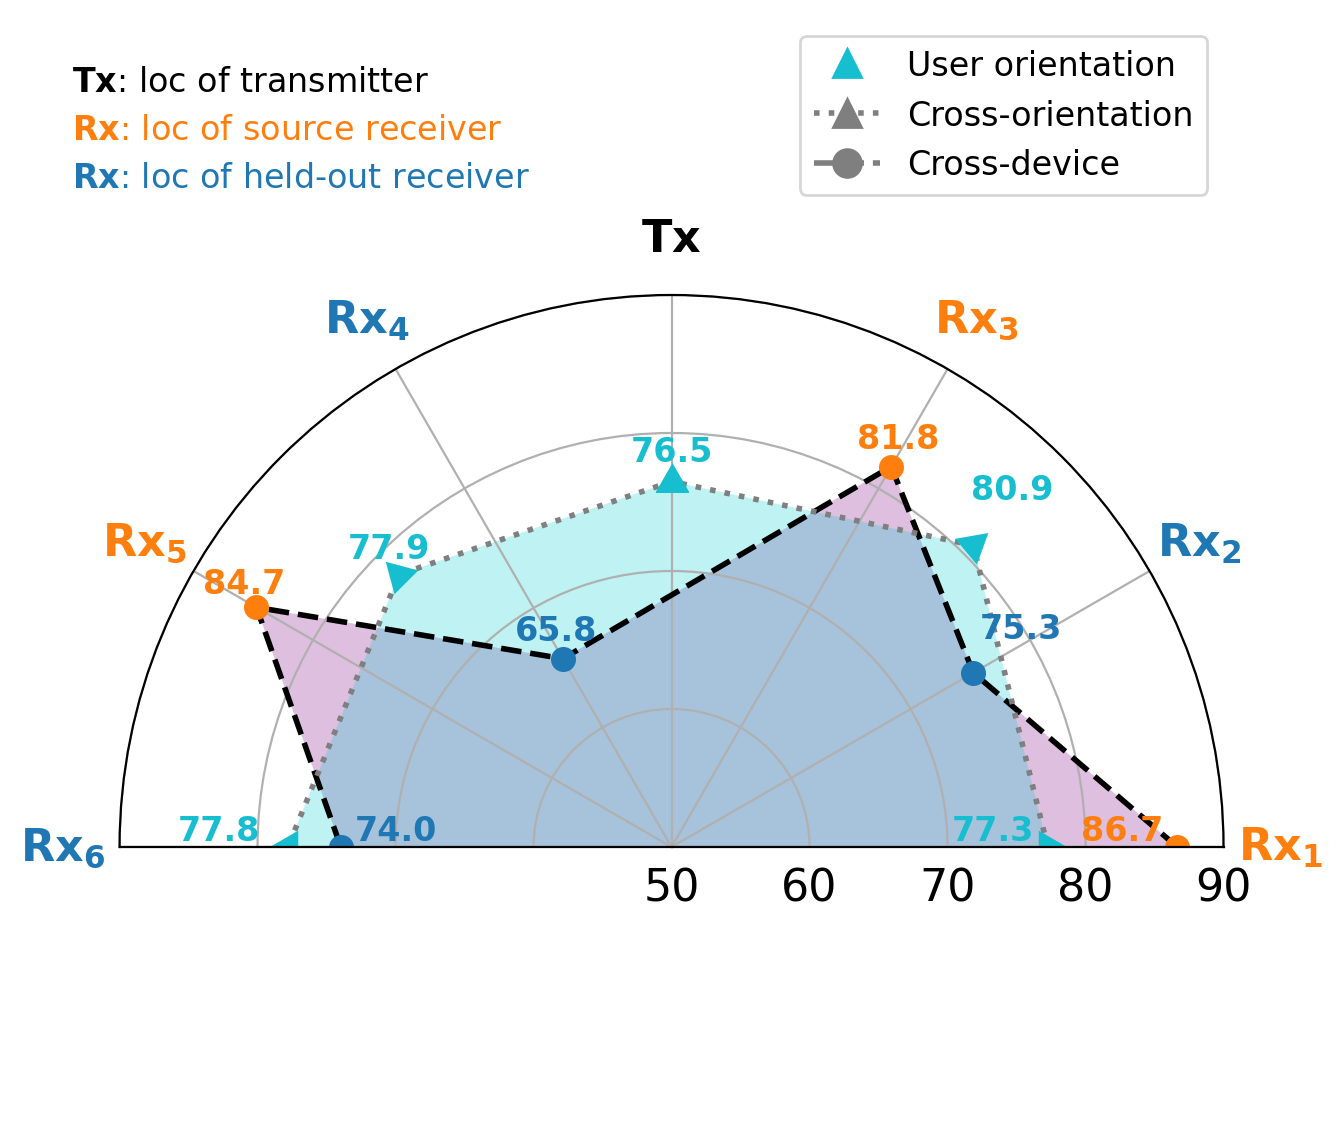

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 16}) 

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 6),dpi=200, subplot_kw=dict(polar=True))


#### Cross device Part #######################
# Data preparation
seen_devices_results = {1: 0.8665568369028006, 3: 0.8183361629881154, 5: 0.8473154362416108}
unseen_devices_results = {2: 0.7525137417884435, 4: 0.6575838926174497, 6: 0.7396433838316128}

# Convert to percentages
all_devices = [1, 2, 3, 4, 5, 6]
baseline_values = [seen_devices_results[1]*100, unseen_devices_results[2]*100, 
              seen_devices_results[3]*100, unseen_devices_results[4]*100,
              seen_devices_results[5]*100, unseen_devices_results[6]*100]

# Create angles for semicircular layout (from 0 to π radians)
angles = [0, np.pi/6, 2*np.pi/6, 4*np.pi/6, 5*np.pi/6, np.pi]

ax.plot(angles, baseline_values, 'k-', linewidth=2, 
        linestyle='dashed', label='Cross-device')

for i, angle in enumerate(angles):
    color = 'tab:orange' if i % 2 == 0 else 'tab:blue'  # tab:orange for seen (1,3,5), tab:blue for unseen (2,4,6)
    ax.plot([angle], [baseline_values[i]], 'o', color=color, markersize=8)
    # Add value text near each point
    # Calculate rotation angle in degrees for text alignment with the polar plot
    rotation_angle = np.degrees(angle)
    # Adjust rotation to keep text readable (0-180 degrees range)
    if rotation_angle > 90 and rotation_angle <= 180:
        rotation_angle -= 180
    # the first two angle need to add 90
    if i in [1,2]:
        rotation_angle -= 90
    # the last two angle need to add 180
    if i in [3,4]:
        rotation_angle += 90
    
    if i == 0:
        ax.text(angle, baseline_values[i] - 4., f'{baseline_values[i]:.1f}', 
            ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    elif i == 5:
        ax.text(angle, baseline_values[i] - 4., f'{baseline_values[i]:.1f}', 
            ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    elif i == 1:
        ax.text(angle, baseline_values[i] +4., f'{baseline_values[i]:.1f}', 
            ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    else:
        ax.text(angle, baseline_values[i] + 1., f'{baseline_values[i]:.1f}', 
                ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    
    # ax.text(angle, baseline_values[i] - 1., f'{baseline_values[i]:.1f}', 
    #             ha='center', va='bottom', fontsize=12, color=color, weight='bold',
    #             rotation=rotation_angle)
    
# Fill the area for baseline
ax.fill(angles, baseline_values, 'purple', alpha=0.25)



##### Cross-orientation part

cross_ori_results = {1: 0.8559556786703602,    # results in the in-domain test
                     2: 0.8846153846153846, 
                     3: 0.8328690807799443,
                     4: 0.8213333333333334,
                     5: 0.83008356545961}

cross_ori_results_2 = {1: 0.6892921146953405,   # the results of the cross-domain test
                     2: 0.7337053571428571, 
                     3: 0.6968001790109645,
                     4: 0.737159446181331, 
                     5: 0.7259325441143623}
# Convert to percentages
all_orientations = [1, 2, 3, 4, 5]
orientation_values = [(cross_ori_results[1]*100 + cross_ori_results_2[1]*100) / 2
                   , (cross_ori_results[2]*100 + cross_ori_results_2[2]*100) / 2
                   , (cross_ori_results[3]*100 + cross_ori_results_2[3]*100) / 2
                   , (cross_ori_results[4]*100 + cross_ori_results_2[4]*100) / 2
                   , (cross_ori_results[5]*100 + cross_ori_results_2[5]*100) / 2]

# Create angles for semicircular layout (from 0 to π radians)
angles = [0, np.pi/4, 2*np.pi/4, 3*np.pi/4, np.pi]

ax.plot(angles, orientation_values, 'k-', linewidth=2, 
        linestyle='dotted', label='Cross-orientation', color='tab:gray')

marker_angle = [-90,70,0,45,90]
for i, angle in enumerate(angles):
    # color = 'tab:orange' if i % 2 == 0 else 'tab:blue'  # tab:orange for seen (1,3,5), tab:blue for unseen (2,4,6)
    color = 'tab:cyan'
    ax.plot([angle], [orientation_values[i]], marker=(3, 0, marker_angle[i]), color=color, markersize=12)
    # Add value text near each point
    # Calculate rotation angle in degrees for text alignment with the polar plot
    rotation_angle = np.degrees(angle)
    # Adjust rotation to keep text readable (0-180 degrees range)
    if rotation_angle > 90 and rotation_angle <= 180:
        rotation_angle -= 180
    # the first two angle need to add 90
    if i in [1,2]:
        rotation_angle -= 90
    # the last two angle need to add 180
    if i in [3,4]:
        rotation_angle += 90
    
    if i == 0:
        ax.text(angle, orientation_values[i] - 4., f'{orientation_values[i]:.1f}', 
            ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    elif i == 4:
        ax.text(angle, orientation_values[i] + 5., f'{orientation_values[i]:.1f}', 
            ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    elif i == 1:
        ax.text(angle, orientation_values[i] +4., f'{orientation_values[i]:.1f}', 
            ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    else:
        ax.text(angle, orientation_values[i] + 1., f'{orientation_values[i]:.1f}', 
                ha='center', va='bottom', fontsize=12, color=color, weight='bold')
    
    # ax.text(angle, baseline_values[i] - 1., f'{baseline_values[i]:.1f}', 
    #             ha='center', va='bottom', fontsize=12, color=color, weight='bold',
    #             rotation=rotation_angle)
 
# Fill the area for baseline
ax.fill(angles, orientation_values, 'darkturquoise', alpha=0.25)




# Set the labels
labels = ['RX1', 'RX2', 'RX3', 'RX4', 'RX5', 'RX6']
rx_colors = ['tab:orange', 'tab:blue', 'tab:orange', 'tab:blue', 'tab:orange', 'tab:blue']  # tab:orange for seen, tab:blue for unseen

# Set y-axis limits and ticks
ax.set_ylim(60, 90)
ax.set_yticks([50, 60, 70, 80, 90])
ax.set_yticklabels(['50', '60', '70', '80', '90'])

# Remove the circular grid lines in the lower half
ax.set_thetamin(0)
ax.set_thetamax(180)

# Add "TX" at the top
# ax.text(np.pi/2, 85, "TX", ha='center', va='center', fontsize=14, weight='bold')

# Add legend-like text elements
plt.figtext(0.2, 0.9, "$\\mathbf{{Tx}}$: loc of transmitter", fontsize=12,)
plt.figtext(0.2, 0.86, "$\\mathbf{{Rx}}$: loc of source receiver", fontsize=12, color='tab:orange')
plt.figtext(0.2, 0.82, "$\\mathbf{{Rx}}$: loc of held-out receiver", fontsize=12, color='tab:blue')


# Create legend with markers and labels
# baseline_patch = mpatches.Patch(color='lightcyan', alpha=0.25, label='Performance')
orientation_marker = mlines.Line2D([], [], color='tab:cyan', marker="^", linestyle='None', markersize=10, label='User orientation')
orentation = mlines.Line2D([], [], color='tab:gray', linestyle='dotted', linewidth=2, label='Cross-orientation', marker="^", markersize=10)
cross_device = mlines.Line2D([], [], color='tab:gray', linestyle='dashed', linewidth=2, label='Cross-device', marker='o', markersize=10)
plt.legend(handles=[orientation_marker, orentation, cross_device], loc='upper right', fontsize=12)



tick_labels = []
for i, label in enumerate(['Rx_1', 'Rx_2', 'Rx_3', 'Tx', 'Rx_4', 'Rx_5', 'Rx_6']):
    if label == 'Tx':
        tick_labels.append(f'$\\mathbf{{{label}}}$')  # TX remains black
    else:
        color = 'tab:orange' if label in ['Rx1', 'Rx3', 'Rx5'] else 'tab:blue'
        tick_labels.append(f'$\\mathbf{{{label}}}$')  # Make bold and apply color in next step

ax.set_xticklabels(tick_labels)
# Apply colors to the tick labels
for i, label in enumerate(ax.get_xticklabels()):
    if i != 3:  # Skip TX (index 3)
        color = 'tab:orange' if i in [0, 2, 5] else 'tab:blue'  # tab:orange for RX1, RX3, RX5; tab:blue for RX2, RX4, RX6
        label.set_color(color)

# Add padding between tick labels and the plot
ax.tick_params(axis='x', pad=10)  # Increase padding between tick labels and plot

plt.tight_layout()

# plt.savefig("figures/v2_cross_deviceANDorientation" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()